# A produção da sua UBS no SISAB, equipe por equipe

**A pergunta:** a minha unidade básica está enviando registros de atendimento?
Quais equipes estão enviando, quanto foi aprovado e como isso se compara ao
município?

**Fonte:** Relatório de Validação do SISAB (Ministério da Saúde) e cadastro de
equipes do CNES, pela biblioteca PySUS.

**Tempo estimado:** 4 a 9 minutos.

> Este é o único exemplo do repositório que chega ao nível da **equipe**. Os
> demais param no município — e a próxima célula explica por quê.

In [2]:
%pip install pysus==2.10.6 nest_asyncio -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
import nest_asyncio
nest_asyncio.apply()

## Por que não dá para usar o SIA aqui

O caminho natural seria o SIA (Sistema de Informações Ambulatoriais), que tem
o campo `PA_CODUNI` com o CNES do estabelecimento. Mas a **Portaria GM/MS nº
2.148/2017** encerrou, na competência de agosto de 2017, a importação dos dados
do e-SUS Atenção Básica para o SIA. Desde então a produção da atenção primária
vai para o SISAB, não para o SIA.

O efeito é grande e silencioso. Medindo o Paraná em janeiro de 2025: das 2.106
UBS cadastradas no CNES, apenas **1.010 aparecem com algum registro no SIA** —
48%. Uma unidade pode fazer milhares de atendimentos e não aparecer ali.

**Nunca leia ausência no SIA como ausência de atendimento.**

In [4]:
# ---- O que você pode trocar -------------------------------------------
CNES_DA_UNIDADE = "2673002"   # CNES de 7 dígitos da sua UBS
IBGE_DO_MUNICIPIO = "410830"  # código IBGE de 6 dígitos (Foz do Iguaçu/PR)
UF = "PR"

# Competências (AAAAMM) que queremos, da mais antiga para a mais recente.
COMPETENCIAS = ["202605", "202606", "202607"]

# Tipo de ficha: 4 = Atendimento Individual, 5 = Atendimento Odontológico,
# 7 = Procedimentos, 8 = Visita Domiciliar, 6 = Atividade Coletiva.
TIPO_DE_FICHA = "4"

## O Relatório de Validação, e por que ele serve

O SISAB publica um **Relatório de Validação** que conta as fichas enviadas por
cada estabelecimento e cada equipe, e diz quantas foram aprovadas. Ele é
público: o endereço tem `acessoRestrito` no caminho, mas não pede login.

O formulário é feito em JSF (uma tecnologia Java), e os identificadores dos
campos mudam a cada versão do site. Por isso a célula abaixo **descobre os
campos pelo conteúdo das opções**, não por nomes fixos — assim o notebook
continua funcionando quando o site for atualizado.

In [5]:
import re
from urllib.parse import urlencode

import httpx
import pandas as pd

URL_SISAB = ("https://sisab.saude.gov.br/paginas/acessoRestrito/relatorio/"
             "federal/envio/RelValidacao.xhtml")


def _campos_do_formulario(html: str) -> dict:
    """Descobre os nomes internos do formulário pelo conteúdo das opções."""
    # O relatório é o segundo formulário da página (o primeiro é o menu).
    formularios = re.findall(r"<form[^>]*>.*?</form>", html, re.S)
    form = max(formularios, key=len)

    campos = {}
    campos["acao"] = re.search(r'action="([^"]+)"', form).group(1)
    campos["form_id"] = re.search(r'id="([^"]+)"', form).group(1)
    campos["view_state"] = re.search(
        r'name="javax\.faces\.ViewState"[^>]*value="([^"]+)"', form).group(1)

    # Cada <select> é identificado pelos valores que oferece.
    for bloco in re.findall(r"<select[^>]*>.*?</select>", form, re.S):
        nome = re.search(r'name="([^"]+)"', bloco)
        if not nome:
            continue
        valores = set(re.findall(r'value="([^"]*)"', bloco))
        if {"202601"} <= valores:
            campos["competencia"] = nome.group(1)
        elif {"1%", "4%"} <= valores:
            campos["validacao"] = nome.group(1)
        elif {"4", "7", "8"} <= valores and "2" in valores:
            campos["ficha"] = nome.group(1)

    # O link "Csv" chama mojarra.jsfcljs(form, {'<id>':'<id>'}, '')
    for onclick, texto in re.findall(r'onclick="([^"]*)"[^>]*>\s*([^<]*)<', form):
        if texto.strip().lower() == "csv":
            campos["botao_csv"] = re.search(r"\{'([^']+)':", onclick).group(1)
    return campos


class ServidorForaDoAr(RuntimeError):
    """O SISAB não respondeu. Não é erro do notebook."""


def baixar_validacao(competencia: str, ficha: str,
                     tentativas: int = 5) -> pd.DataFrame:
    """Baixa uma competência inteira do Relatório de Validação (Brasil).

    Tenta mais de uma vez de propósito. O servidor do Ministério sai do ar por
    minutos, sem aviso: enquanto este notebook era escrito ele caiu duas vezes
    e voltou sozinho nas duas. As esperas somam pouco mais de um minuto, o que
    cobre um soluço mas não uma queda longa — e quando não cobre, a mensagem
    diz de quem é a culpa em vez de despejar um traceback.
    """
    import time

    esperas = [3, 8, 20, 40]
    for tentativa in range(1, tentativas + 1):
        try:
            return _baixar_uma_vez(competencia, ficha)
        except Exception as erro:
            if tentativa == tentativas:
                raise ServidorForaDoAr(
                    f"O servidor do SISAB não respondeu depois de {tentativas} "
                    f"tentativas ({type(erro).__name__}).\n\n"
                    "Isso NÃO é erro do notebook nem do seu computador: o "
                    "sisab.saude.gov.br sai do ar por alguns minutos de vez em "
                    "quando e volta sozinho. Espere um pouco e execute esta "
                    "célula de novo.\n\n"
                    "Para conferir se é isso, abra no navegador: "
                    "https://sisab.saude.gov.br/paginas/acessoRestrito/"
                    "relatorio/federal/envio/RelValidacao.xhtml"
                ) from erro
            espera = esperas[min(tentativa - 1, len(esperas) - 1)]
            print(f"   tentativa {tentativa} falhou ({type(erro).__name__}); "
                  f"repetindo em {espera}s...")
            time.sleep(espera)


def _baixar_uma_vez(competencia: str, ficha: str) -> pd.DataFrame:
    with httpx.Client(timeout=600, follow_redirects=True) as cliente:
        pagina = cliente.get(URL_SISAB)
        pagina.raise_for_status()
        c = _campos_do_formulario(pagina.text)

        formulario = [
            (c["form_id"], c["form_id"]),
            ("unidGeo", "brasil"),
            ("periodo", "producao"),
            (c["competencia"], competencia),
            ("colunas", "ibge"), ("colunas", "municipio"),
            ("colunas", "cnes"), ("colunas", "tp_unidade"),
            ("colunas", "ine"), ("colunas", "tp_equipe"),
            (c["validacao"], "1%"),          # somente Aprovado
            (c["ficha"], ficha),
            ("javax.faces.ViewState", c["view_state"]),
            (c["botao_csv"], c["botao_csv"]),
        ]
        # O formulario repete a chave "colunas" varias vezes. Montamos o
        # corpo a mao porque isso nao passa por um dicionario comum.
        corpo = urlencode(formulario)
        resposta = cliente.post(
            "https://sisab.saude.gov.br" + c["acao"],
            content=corpo,
            headers={"Content-Type": "application/x-www-form-urlencoded"},
        )
        resposta.raise_for_status()

    # O arquivo vem em ISO-8859-1 e traz linhas de cabeçalho antes da tabela.
    texto = resposta.content.decode("iso-8859-1", errors="replace")
    linhas = texto.splitlines()
    inicio = next(i for i, l in enumerate(linhas) if l.startswith("IBGE;"))
    from io import StringIO
    tabela = pd.read_csv(StringIO("\n".join(linhas[inicio:])), sep=";",
                         dtype=str, index_col=False)
    tabela = tabela.loc[:, [c for c in tabela.columns
                            if not c.startswith("Unnamed")]]
    tabela["competencia"] = competencia
    tabela["CNES"] = tabela["CNES"].astype(str).str.strip().str.zfill(7)
    # Ha linhas sem equipe informada; nao as transforme em INE falso.
    ine = tabela["INE"].astype("string").str.strip()
    tabela["INE"] = ine.where(ine.notna() & (ine != ""), pd.NA).str.zfill(10)
    tabela["fichas"] = pd.to_numeric(
        tabela["Total"].astype(str).str.replace(".", "", regex=False),
        errors="coerce")
    return tabela


print("Funções prontas.")

Funções prontas.


## Baixando as competências

Cada competência é um arquivo nacional de uns 6 MB. Baixamos o país inteiro
porque o relatório entrega tudo de uma vez, e depois filtramos aqui — é mais
simples e mais rápido do que navegar pelos filtros de estado e município.

In [6]:
partes = []
for competencia in COMPETENCIAS:
    tabela = baixar_validacao(competencia, TIPO_DE_FICHA)
    print(f"{competencia}: {len(tabela):,} linhas, "
          f"{tabela['CNES'].nunique():,} estabelecimentos, "
          f"{tabela['INE'].nunique():,} equipes")
    partes.append(tabela)

validacao = pd.concat(partes, ignore_index=True)
print(f"\nTotal reunido: {len(validacao):,} linhas")
print("Colunas:", validacao.columns.tolist())

202605: 102,170 linhas, 44,838 estabelecimentos, 72,279 equipes


202606: 102,668 linhas, 44,931 estabelecimentos, 72,557 equipes


202607: 102,923 linhas, 44,987 estabelecimentos, 72,384 equipes
Total reunido: 307,761 linhas
Colunas: ['IBGE', 'Municipio', 'CNES', 'Tipo Unidade', 'INE', 'Tipo Equipe', 'Validação', 'Total', 'competencia', 'fichas']


## A sua unidade

Agora filtramos pelo CNES. Cada linha é uma equipe naquela competência.

In [7]:
unidade = validacao[validacao["CNES"] == CNES_DA_UNIDADE].copy()

if unidade.empty:
    print(f"Nenhum registro para o CNES {CNES_DA_UNIDADE} nestas competências.")
    print("Verifique o número, ou tente outro tipo de ficha (TIPO_DE_FICHA).")
else:
    print(f"CNES {CNES_DA_UNIDADE}: {len(unidade)} linhas, "
          f"{unidade['INE'].nunique()} equipes distintas")
    print(f"Fichas aprovadas no período: {unidade['fichas'].sum():,.0f}")
    display(unidade[["competencia", "INE", "Tipo Equipe", "fichas"]])

CNES 2673002: 15 linhas, 4 equipes distintas
Fichas aprovadas no período: 5,715


,competencia,INE,Tipo Equipe,fichas
4227,202605,0002019426,70,425.0
27834,202605,0000384895,76,533.0
29477,202605,<NA>,NaN,50.0
42085,202605,0002399067,70,293.0
53545,202605,0002019388,70,593.0
102641,202606,0002019426,70,354.0
137203,202606,0000384895,76,538.0
137808,202606,<NA>,NaN,29.0
144025,202606,0002399067,70,396.0
160586,202606,0002019388,70,583.0


## Trocando os números das equipes por nomes

O relatório traz o INE, o número da equipe. O nome vem do cadastro de equipes
do CNES, que a PySUS baixa.

Aqui há um detalhe que economiza muito tempo: no CNES o campo se chama
`IDEQUIPE` e tem 18 dígitos — é o código do município, uma sequência e, nos
**últimos 8 dígitos, o INE**. Basta recortar.

In [8]:
from pysus import cnes, list_files

# O CNES costuma estar algumas competencias atras do SISAB. Em vez de
# adivinhar, perguntamos ao catalogo qual e a mais recente que existe.
ano_ep = int(COMPETENCIAS[-1][:4])
catalogo_ep = list_files("CNES", group="EP", state=UF, year=ano_ep)
mes_ep = int(catalogo_ep["month"].dropna().astype(int).max())
print(f"Cadastro de equipes mais recente disponivel: {mes_ep:02d}/{ano_ep}")

equipes = cnes(UF, ano_ep, mes_ep, group="EP", as_dataframe=True)
equipes["CNES"] = equipes["CNES"].astype(str).str.zfill(7)
# Os últimos 8 dígitos do IDEQUIPE são o INE usado pelo SISAB.
equipes["INE"] = (equipes["IDEQUIPE"].astype(str).str.strip()
                  .str[-8:].str.zfill(10))

nomes = (equipes[equipes["CNES"] == CNES_DA_UNIDADE]
         [["INE", "NOME_EQP", "TIPO_EQP", "DT_ATIVA", "DT_DESAT"]])
print("Equipes cadastradas nesta unidade:")
display(nomes)

Cadastro de equipes mais recente disponivel: 07/2026


Equipes cadastradas nesta unidade:


,INE,NOME_EQP,TIPO_EQP,DT_ATIVA,DT_DESAT
2792,0000384887,AKLP,04,200410,201110
2793,0000384895,EQUIPE 3,76,201111,900001
2794,0002019388,EQUIPE 1,70,202006,900001
2795,0002209586,EQUIPE 3 SB,71,202109,900001
2796,0002019426,EQUIPE 2,70,202006,900001
2797,0002019434,EQUIPE 1 SB,71,202006,900001
2798,0002399067,EQUIPE 4,70,202310,900001


In [9]:
com_nome = unidade.merge(nomes[["INE", "NOME_EQP"]], on="INE", how="left")
com_nome["equipe"] = com_nome["NOME_EQP"].fillna("(sem equipe informada)")
# Linhas sem INE NAO sao erro de cadastro: o art. 311 da Portaria de
# Consolidacao 1/2017, na redacao da Portaria 7.639/2025, obriga a enviar ao
# Siaps tambem os profissionais lotados na unidade que nao fazem parte de
# equipe com INE. Elas sao esperadas.

painel = com_nome.pivot_table(index="equipe", columns="competencia",
                              values="fichas", aggfunc="sum").fillna(0)
print("Fichas aprovadas por equipe e competência:")
display(painel.astype(int))

Fichas aprovadas por equipe e competência:


competencia,202605,202606,202607
equipe,,,
(sem equipe informada),50,29,36
EQUIPE 1,593,583,783
EQUIPE 2,425,354,239
EQUIPE 3,533,538,313
EQUIPE 4,293,396,550


## O gráfico

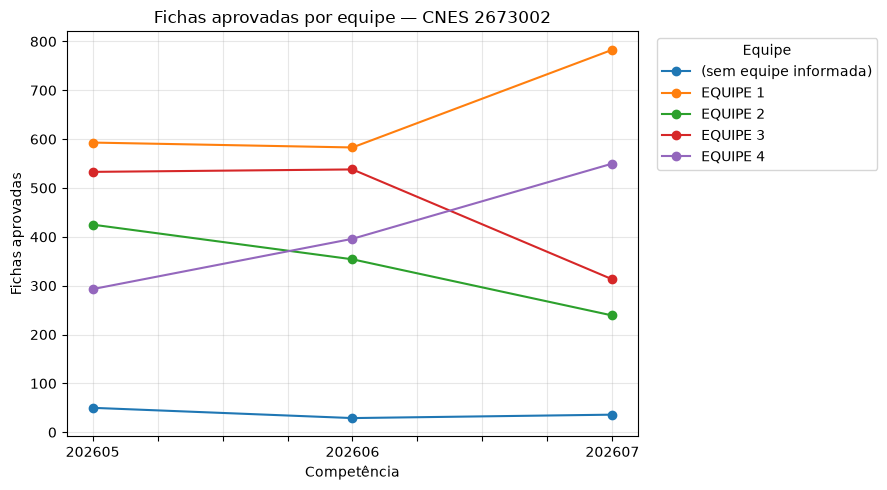

In [10]:
import matplotlib.pyplot as plt

eixo = painel.T.plot(kind="line", marker="o", figsize=(9, 5))
eixo.set_title(f"Fichas aprovadas por equipe — CNES {CNES_DA_UNIDADE}")
eixo.set_xlabel("Competência")
eixo.set_ylabel("Fichas aprovadas")
eixo.legend(title="Equipe", bbox_to_anchor=(1.02, 1), loc="upper left")
eixo.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Conferindo contra o município

Um número sozinho engana. A participação da unidade no total do município
mostra se o resultado é plausível: se a sua UBS aparecer com mais fichas que o
município inteiro, algo está errado no filtro.

In [11]:
municipio = validacao[validacao["IBGE"].astype(str) == IBGE_DO_MUNICIPIO]

for competencia in COMPETENCIAS:
    total_mun = municipio.loc[municipio["competencia"] == competencia,
                              "fichas"].sum()
    total_ubs = unidade.loc[unidade["competencia"] == competencia,
                            "fichas"].sum()
    unidades = municipio.loc[municipio["competencia"] == competencia,
                             "CNES"].nunique()
    parcela = (total_ubs / total_mun * 100) if total_mun else 0
    print(f"{competencia}: município {total_mun:>9,.0f} fichas em {unidades:>3} "
          f"estabelecimentos | esta unidade {total_ubs:>7,.0f} ({parcela:.1f}%)")

202605: município    45,793 fichas em  29 estabelecimentos | esta unidade   1,894 (4.1%)
202606: município    43,406 fichas em  29 estabelecimentos | esta unidade   1,900 (4.4%)
202607: município    48,074 fichas em  29 estabelecimentos | esta unidade   1,921 (4.0%)


## Lendo o resultado

Repare no que a comparação municipal mostra: a participação da unidade fica
praticamente constante (por volta de 4%) nas três competências, mesmo quando o
total cai bastante na última. Ou seja, a queda não é da unidade — é do
município inteiro, e a explicação mais provável é que a competência mais
recente ainda esteja sendo consolidada.

Essa é a razão de sempre comparar com o município antes de concluir qualquer
coisa sobre uma equipe.

## Três ressalvas que mudam a leitura

**1. Isto são fichas, não atendimentos.** O Relatório de Validação conta
fichas enviadas e validadas. Uma ficha pode carregar mais de uma informação.
Ele responde bem a "a unidade está enviando? quais equipes? quanto foi
aprovado?" — e não responde "quantas consultas foram feitas".

**2. Linhas "sem equipe informada" são esperadas, não erro.** O art. 311 da
Portaria de Consolidação nº 1/2017, na redação dada pela Portaria GM/MS nº
7.639/2025, obriga a enviar ao Siaps também os profissionais lotados na
unidade que **não fazem parte de equipe com INE**. Quando essas linhas
aparecerem, não conclua que o cadastro está incompleto.

**3. O tipo de ficha decide quais equipes aparecem.** Com
`TIPO_DE_FICHA = "4"` (Atendimento Individual) as equipes de saúde bucal não
aparecem: elas registram em `"5"` (Atendimento Odontológico). Se uma equipe que
você conhece sumir do resultado, troque o tipo de ficha antes de concluir que
ela não produziu.

## Como adaptar

- **Outra unidade:** troque `CNES_DA_UNIDADE` e `IBGE_DO_MUNICIPIO`. O CNES da
  sua unidade está no cartão do estabelecimento, ou no site do CNES.
- **Outro período:** acrescente competências em `COMPETENCIAS`, no formato
  `AAAAMM`. O relatório cobre de janeiro de 2021 em diante.
- **Saúde bucal:** `TIPO_DE_FICHA = "5"`.
- **Ver o que foi reprovado:** no lugar de `("validacao", "1%")` use `"4%"`
  (Reprovado), `"2%"` (Duplicado) ou `"3%"` (Data inválida). Comparar aprovado
  com reprovado costuma revelar problema de cadastro de CNES, INE ou CBO.

---

*Exemplo do PySusNoCode — [kraemeracademy.net](https://kraemeracademy.net).
Dados públicos do Ministério da Saúde (SISAB) e do CNES, via PySUS.*

## Verificação de sanidade

Toda análise deste repositório termina conferindo o próprio resultado. Não é
formalidade: uma mudança no catálogo do DATASUS já fez notebooks devolverem o
Brasil inteiro rotulado como um estado, **sem erro nenhum**. Falhar alto é
incômodo; acertar o formato e errar o número vira decisão errada.

In [ ]:
print("Verificações\n")
falhas = []


def conferir(numero, descricao, condicao, detalhe=""):
    marca = "confere" if condicao else "ATENÇÃO"
    print(f"{numero}. {descricao}{(' — ' + detalhe) if detalhe else ''}: {marca}")
    if not condicao:
        falhas.append(descricao)

conferir(1, "O SISAB devolveu o relatório",
         len(validacao) > 0, f"{len(validacao):,} linhas")
conferir(2, "A unidade pedida aparece no relatório",
         len(unidade) > 0, f"CNES {CNES_DA_UNIDADE}, {len(unidade)} linhas")
conferir(3, "Todas as competências pedidas vieram",
         set(str(c) for c in unidade["competencia"].unique()) == set(COMPETENCIAS)
         if "competencia" in unidade.columns else True,
         f"{len(COMPETENCIAS)} pedidas")

# O INE tem 10 digitos: se vier com menos, a juncao com o CNES falha em silencio
# So os INE PREENCHIDOS: as linhas sem INE sao legitimas (art. 311), e
# .astype(str) transformava o <NA> na string "<NA>", de 4 caracteres — o
# tamanho 4 que aparecia aqui era invencao minha, nao do dado.
if "INE" in com_nome.columns:
    preenchidos = com_nome["INE"].dropna().astype(str)
    tamanhos = set(preenchidos.str.len().unique())
    conferir(4, "Todo INE preenchido tem 10 dígitos", tamanhos == {10},
             f"{len(preenchidos)} de {len(com_nome)} linhas têm INE; "
             f"tamanhos: {sorted(tamanhos)}")

# a soma das equipes tem de bater com o total da unidade
if "fichas" in unidade.columns:
    conferir(5, "A soma das equipes bate com o total da unidade",
             abs(unidade["fichas"].sum() - painel.values.sum()) < 1
             if hasattr(painel, "values") else True)

print()
if falhas:
    print("ATENÇÃO: revise antes de usar estes números —", falhas)
else:
    print("Tudo confere.")